#**Análise de dados, ETL e Machine Learning**



##**Academia Club4**

###1- Importação sdas bibliotecas utilizadas e extração do arquivo CSV

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('/content/academia_redfit.csv')
df.head(20)

,idade,sexo,frequencia_semanal_treino,tipo_atividade,tempo_medio_exercicio,minutos_totais_semana,preco_plano,possui_nutricionista,primeiro_PGC,ultimo_PGC,data_matricula,estado
0,48,Outro,7.0,Natação,45.3,317.1,188.47,Não,39.5,24.9,2021-07-28,Ativa
1,30,Outro,7.0,Yoga,98.1,686.7,198.07,Não,25.2,23.5,2020-12-28,Ativa
2,35,Masculino,5.0,Cardio,33.9,169.5,154.90,Não,27.2,11.4,2022-02-27,Ativa
3,43,Outro,3.0,Yoga,75.6,226.8,250.79,Sim,14.4,19.2,2022-12-01,Ativa
4,37,Masculino,0.0,CrossFit,114.0,0.0,168.02,Sim,21.5,18.1,2024-01-20,Sedentária
5,57,Masculino,2.0,Yoga,95.5,191.0,74.06,Não,35.8,14.4,2020-04-26,Ativa
6,55,Masculino,7.0,CrossFit,95.7,669.9,289.13,Sim,16.1,14.9,2022-06-12,Ativa
7,21,Feminino,5.0,Yoga,117.5,587.5,259.55,Não,13.2,13.5,2021-09-07,Ativa
8,37,Masculino,7.0,Yoga,NaN,NaN,194.34,Sim,18.4,21.8,2025-09-02,Ativa
9,50,Masculino,1.0,Musculação,105.0,105.0,290.91,Sim,37.3,31.0,2020-05-06,Ativa


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   idade                      1000 non-null   int64  
 1   sexo                       1000 non-null   object 
 2   frequencia_semanal_treino  949 non-null    float64
 3   tipo_atividade             1000 non-null   object 
 4   tempo_medio_exercicio      954 non-null    float64
 5   minutos_totais_semana      905 non-null    float64
 6   preco_plano                1000 non-null   float64
 7   possui_nutricionista       1000 non-null   object 
 8   primeiro_PGC               1000 non-null   float64
 9   ultimo_PGC                 1000 non-null   float64
 10  data_matricula             1000 non-null   object 
 11  estado                     1000 non-null   object 
dtypes: float64(6), int64(1), object(5)
memory usage: 93.9+ KB


####Verificação dos dados e padronização

In [58]:
df['data_matricula'] = pd.to_datetime(df['data_matricula'])

In [59]:
print(df['sexo'].unique())

['Outro' 'Masculino' 'Feminino']


In [74]:
df.loc[df['estado'] == 'Sedentária', 'minutos_totais_semana'] = df.loc[df['estado'] == 'Sedentária', 'minutos_totais_semana'].fillna(0)
df.loc[df['estado'] == 'Sedentária', 'frequencia_semanal_treino'] = df.loc[df['estado'] == 'Sedentária', 'frequencia_semanal_treino'].fillna(0.0)
df.loc[df['estado'] == 'Ativa', 'minutos_totais_semana'] = df.loc[df['estado'] == 'Ativa', 'minutos_totais_semana'].fillna(df['minutos_totais_semana'].mean().round(2))
df.loc[df['estado'] == 'Ativa', 'tempo_medio_exercicio'] = df.loc[df['estado'] == 'Ativa', 'tempo_medio_exercicio'].fillna(df['tempo_medio_exercicio'].mean().round(2))
df.loc[df['estado'] == 'Sedentária', 'tempo_medio_exercicio'] = df.loc[df['estado'] == 'Sedentária', 'tempo_medio_exercicio'].fillna(0.0)
df.loc[df['estado'] == 'Ativa', 'frequencia_semanal_treino'] = df.loc[df['estado'] == 'Ativa', 'frequencia_semanal_treino'].fillna(df['frequencia_semanal_treino'].median())

In [61]:
df.head(20)

,idade,sexo,frequencia_semanal_treino,tipo_atividade,tempo_medio_exercicio,minutos_totais_semana,preco_plano,possui_nutricionista,primeiro_PGC,ultimo_PGC,data_matricula,estado
0,48,Outro,7.0,Natação,45.30,317.10,188.47,Não,39.5,24.9,2021-07-28,Ativa
1,30,Outro,7.0,Yoga,98.10,686.70,198.07,Não,25.2,23.5,2020-12-28,Ativa
2,35,Masculino,5.0,Cardio,33.90,169.50,154.90,Não,27.2,11.4,2022-02-27,Ativa
3,43,Outro,3.0,Yoga,75.60,226.80,250.79,Sim,14.4,19.2,2022-12-01,Ativa
4,37,Masculino,0.0,CrossFit,114.00,0.00,168.02,Sim,21.5,18.1,2024-01-20,Sedentária
5,57,Masculino,2.0,Yoga,95.50,191.00,74.06,Não,35.8,14.4,2020-04-26,Ativa
6,55,Masculino,7.0,CrossFit,95.70,669.90,289.13,Sim,16.1,14.9,2022-06-12,Ativa
7,21,Feminino,5.0,Yoga,117.50,587.50,259.55,Não,13.2,13.5,2021-09-07,Ativa
8,37,Masculino,7.0,Yoga,70.14,232.85,194.34,Sim,18.4,21.8,2025-09-02,Ativa
9,50,Masculino,1.0,Musculação,105.00,105.00,290.91,Sim,37.3,31.0,2020-05-06,Ativa


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   idade                      1000 non-null   int64         
 1   sexo                       1000 non-null   int64         
 2   frequencia_semanal_treino  1000 non-null   float64       
 3   tipo_atividade             1000 non-null   int64         
 4   tempo_medio_exercicio      1000 non-null   float64       
 5   minutos_totais_semana      1000 non-null   float64       
 6   preco_plano                1000 non-null   float64       
 7   possui_nutricionista       1000 non-null   int64         
 8   primeiro_PGC               1000 non-null   float64       
 9   ultimo_PGC                 1000 non-null   float64       
 10  data_matricula             1000 non-null   datetime64[ns]
 11  estado                     1000 non-null   object        
 12  evoluca

####Adição das tabelas de Evolução do PGC e IMC estimado

In [63]:
df['evolucao_pgc'] = df['primeiro_PGC'] - df['ultimo_PGC']
df['imc_estimado'] = (df['primeiro_PGC'] * 1.2) + (df['idade'] * 0.05)

In [64]:
df.head(20)

,idade,sexo,frequencia_semanal_treino,tipo_atividade,tempo_medio_exercicio,minutos_totais_semana,preco_plano,possui_nutricionista,primeiro_PGC,ultimo_PGC,data_matricula,estado,evolucao_pgc,imc_estimado
0,48,Outro,7.0,Natação,45.30,317.10,188.47,Não,39.5,24.9,2021-07-28,Ativa,14.6,49.80
1,30,Outro,7.0,Yoga,98.10,686.70,198.07,Não,25.2,23.5,2020-12-28,Ativa,1.7,31.74
2,35,Masculino,5.0,Cardio,33.90,169.50,154.90,Não,27.2,11.4,2022-02-27,Ativa,15.8,34.39
3,43,Outro,3.0,Yoga,75.60,226.80,250.79,Sim,14.4,19.2,2022-12-01,Ativa,-4.8,19.43
4,37,Masculino,0.0,CrossFit,114.00,0.00,168.02,Sim,21.5,18.1,2024-01-20,Sedentária,3.4,27.65
5,57,Masculino,2.0,Yoga,95.50,191.00,74.06,Não,35.8,14.4,2020-04-26,Ativa,21.4,45.81
6,55,Masculino,7.0,CrossFit,95.70,669.90,289.13,Sim,16.1,14.9,2022-06-12,Ativa,1.2,22.07
7,21,Feminino,5.0,Yoga,117.50,587.50,259.55,Não,13.2,13.5,2021-09-07,Ativa,-0.3,16.89
8,37,Masculino,7.0,Yoga,70.14,232.85,194.34,Sim,18.4,21.8,2025-09-02,Ativa,-3.4,23.93
9,50,Masculino,1.0,Musculação,105.00,105.00,290.91,Sim,37.3,31.0,2020-05-06,Ativa,6.3,47.26


###Salvando/Carregando o CSV limpo

In [52]:
df.to_csv('academia_club4_limpo.csv', index=False)

###Gerando os gráficos

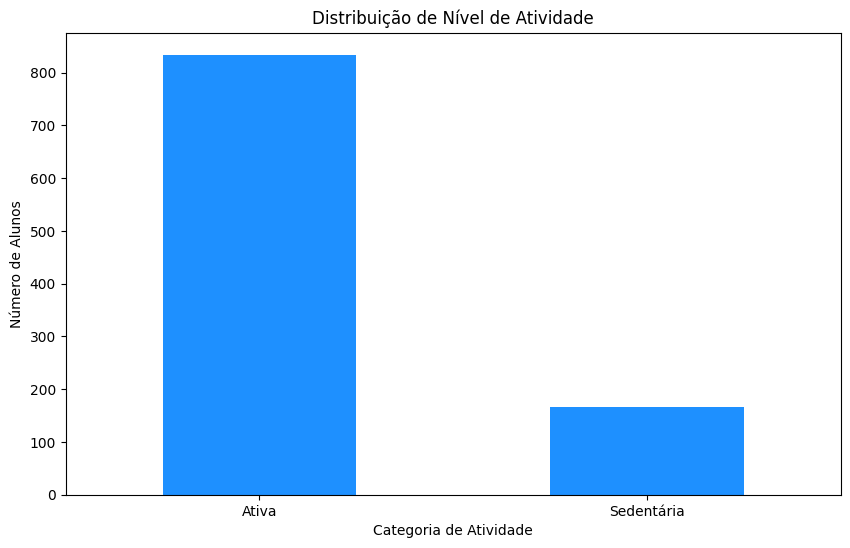

In [65]:
plt.figure(figsize=(10,6))
df['estado'].value_counts().plot(kind='bar', color='dodgerblue')
plt.title('Distribuição de Nível de Atividade')
plt.xlabel('Categoria de Atividade')
plt.ylabel('Número de Alunos')
plt.xticks(rotation=0)
plt.show()

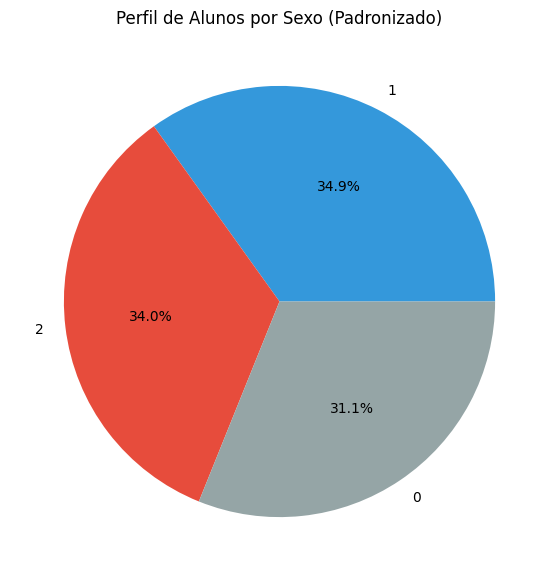

In [77]:
plt.figure(figsize=(7,7))
df['sexo'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#3498db', '#e74c3c', '#95a5a6'])
plt.title('Perfil de Alunos por Sexo (Padronizado)')
plt.ylabel('')
plt.show()

##Algoritmo completo para a classificação


In [80]:
from re import X
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv('academia_club4_limpo.csv')

#Processamento dos dados (passagem para valores numéricos)

le_sexo = LabelEncoder()
df['sexo'] = le_sexo.fit_transform(df['sexo'])

le_atividade = LabelEncoder()
df['tipo_atividade'] = le_atividade.fit_transform(df['tipo_atividade'])

le_nutri = LabelEncoder()
df['possui_nutricionista'] = le_nutri.fit_transform(df['possui_nutricionista'])

#Leitura da duração da matrícula

df['data_matricula'] = pd.to_datetime(df['data_matricula'])
df['dias_de_matricula'] = (pd.Timestamp('now') - df['data_matricula']).dt.days

#Separação dos dados de teste dos resultados

X = df[['idade', 'sexo', 'primeiro_PGC', 'evolucao_pgc', 'tipo_atividade', 'preco_plano', 'dias_de_matricula']]
y = df['estado'] #O nosso resultado que será oculto durante a fase de treianemento

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

modelo = RandomForestClassifier(
    n_estimators=500,
    max_depth=7,
    class_weight='balanced',
    random_state=42
)

modelo.fit(X_train, y_train)

previsoes = modelo.predict(X_test)
acuracia = accuracy_score(y_test, previsoes)

# Conclusão do modelo

print(f"Acurácia do Modelo Otimizado: {acuracia * 100:.2f}%")
print("\nRelatório de Classificação Detalhado:")
print(classification_report(y_test, previsoes))

Acurácia do Modelo Otimizado: 81.00%

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

       Ativa       0.84      0.96      0.89       250
  Sedentária       0.23      0.06      0.10        50

    accuracy                           0.81       300
   macro avg       0.53      0.51      0.49       300
weighted avg       0.74      0.81      0.76       300

